In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [7]:
from tavily import TavilyClient
from typing import Literal

tavily_client=TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

def web_search(query:str,max_results:int=5,
topic: Literal["general","sports","news","finance"]="general",
include_raw_content:bool=False):
    """Run a web search"""
    return tavily_client.search(query,
    max_results=max_results,include_raw_content=include_raw_content,topic=topic)



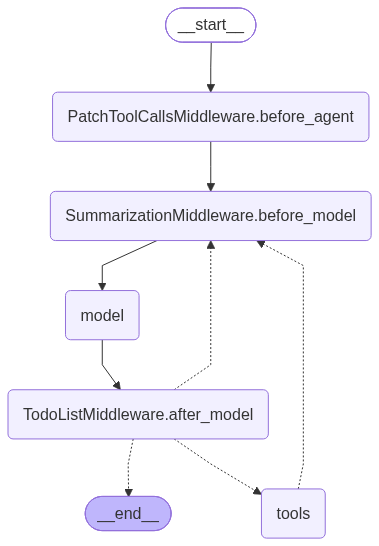

In [ ]:
## create a deep agent
from deepagents import create_deep_agent
from langchain_groq import ChatGroq
from langchain.agents.middleware import TodoListMiddleware, SummarizationMiddleware

model = ChatGroq(model="llama-3.1-8b-instant")
deepagent = create_deep_agent(model=model, 
tools=[web_search], 
system_prompt="Act as a researcher",
middleware=[
        # 1. Summarizes old chat history when token thresholds are reached
        SummarizationMiddleware(
            model=model,
            trigger=("tokens", 4000),  # Compress when total tokens hit 4000
            keep=("messages", 20)      # Always keep the 20 most recent messages intact
        ),
        # 2. Tracks task execution steps
        TodoListMiddleware() 
    ])

deepagent

In [16]:
result = deepagent.invoke({"messages": [{"role": "user", "content": "What is langgraph?"}]})
result

NotFoundError: Error code: 404 - {'error': {'message': 'The model `gpt-4o` does not exist or you do not have access to it.', 'type': 'invalid_request_error', 'code': 'model_not_found'}}